#### Exploration des données HDFS_v1

### Configuration de l'environnement


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import re

# Configuration des graphiques
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

# Chemins des fichiers
DATA_DIR = "../data/"
OUTPUT_DIR = "../outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Vérification des fichiers disponibles
print("Fichiers disponibles dans le répértoire:")
for f in sorted(os.listdir(DATA_DIR)):
    size = os.path.getsize(os.path.join(DATA_DIR, f))
    print(f"  {f:40s} ({size/1024/1024:.1f} MB)")


Fichiers disponibles dans le répértoire:
  Event_occurrence_matrix.csv              (50.6 MB)
  Event_traces.csv                         (119.6 MB)
  HDFS.log                                 (1504.9 MB)
  HDFS.log_templates.csv                   (0.0 MB)
  HDFS.npz                                 (50.5 MB)
  README.md                                (0.0 MB)
  anomaly_label.csv                        (17.8 MB)


#### 1. Chargement des étiquettes (anomaly_label.csv)
Ce fichier contient le label Normal/Anomaly pour chaque `block_id`.


In [3]:
# Chargement du fichier d'étiquettes
labels_df = pd.read_csv(os.path.join(DATA_DIR, "anomaly_label.csv"))

print(f"Dimensions : {labels_df.shape}")
print(f"Colonnes :   {labels_df.columns.tolist()}")
print()
labels_df.head(10)

Dimensions : (575061, 2)
Colonnes :   ['BlockId', 'Label']



,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal
5,blk_1717858812220360316,Normal
6,blk_-2519617320378473615,Normal
7,blk_7063315473424667801,Normal
8,blk_8586544123689943463,Normal
9,blk_2765344736980045501,Normal


In [4]:
# Distribution des labels
label_counts = labels_df['Label'].value_counts()
anomaly_ratio = label_counts.get('Anomaly', 0) / len(labels_df) * 100

print(f"Distribution des labels :")
print(label_counts)
print(f"\nTaux d'anomalie : {anomaly_ratio:.2f}%")


Distribution des labels :
Label
Normal     558223
Anomaly     16838
Name: count, dtype: int64

Taux d'anomalie : 2.93%


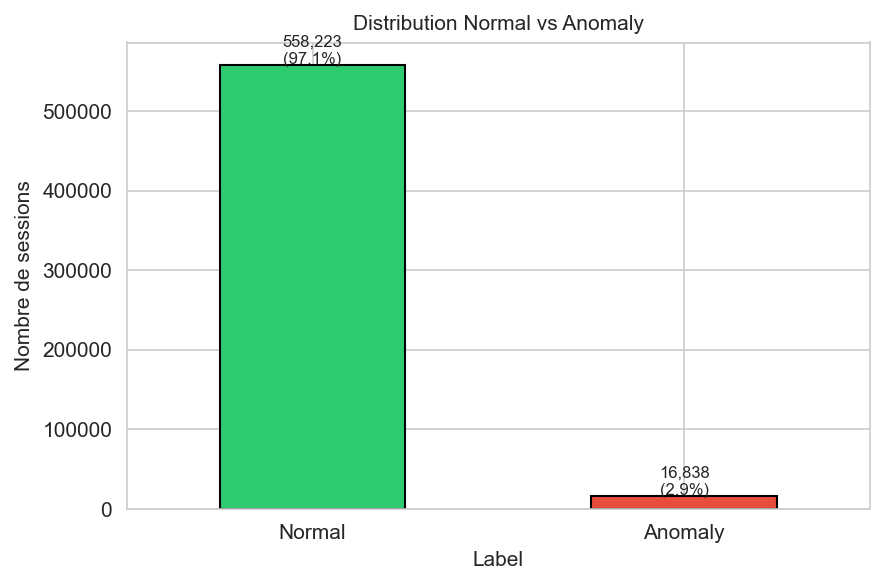

In [5]:
# Visualisation de la distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
label_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Distribution Normal vs Anomaly', fontsize=10)
ax.set_ylabel('Nombre de sessions')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (val, name) in enumerate(zip(label_counts.values, label_counts.index)):
    ax.text(i, val + 1000, f"{val:,}\n({val/len(labels_df)*100:.1f}%)", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution.png"))
plt.show()


#### 2. Aperçu du fichier de log brut (HDFS.log)
Examiner le format réel des lignes de log pour définir la stratégie de parsing.


In [7]:
# Affichage des premières lignes
log_path = os.path.join(DATA_DIR, "HDFS.log")

print("=" * 90)
print("Premières 15 lignes de HDFS.log")
print("=" * 90)

with open(log_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 15:
            break
        print(f"[{i:>3}] {line.strip()}")


Premières 15 lignes de HDFS.log
[  0] 081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
[  1] 081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
[  2] 081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010
[  3] 081109 203519 145 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010
[  4] 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_-1608999687919862906 terminating
[  5] 081109 203519 145 INFO dfs.DataNode$PacketResponder: PacketResponder 2 for block blk_-1608999687919862906 terminating
[  6] 081109 203519 145 INFO dfs.DataNode$PacketResponder: Received block blk_-1608999687919862906 of size 91178 fro

#### Observation

 Format identifié
```
YYMMDD HHMMSS PID LEVEL COMPOSANT: CONTENU
081109 203615 148 INFO  dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_3886504...
```

**Champs à extraire :**
| Champ | Exemple | Description |
|-------|---------|-------------|
| date | 081109 | Date (AAMMJJ) |
| time | 203615 | Heure (HHMMSS) |
| pid | 148 | Identifiant du processus |
| level | INFO | Niveau de log |
| component | dfs.DataNode$PacketResponder | Composant source |
| content | PacketResponder 1 for block... | Contenu du message |
| block_id | blk_38865049064139660 | Extrait du contenu |


#### 3. Statistiques globales du fichier de log


In [8]:
# Analyse complète du fichier de log brut

line_count = 0
log_levels = Counter()
block_ids = set()
components = Counter()

block_pattern = re.compile(r'(blk_-?\d+)')
level_pattern = re.compile(r'\s(INFO|WARN|ERROR|FATAL)\s')
component_pattern = re.compile(r'(?:INFO|WARN|ERROR|FATAL)\s(\S+?):')

with open(log_path, 'r') as f:
    for line in f:
        line_count += 1
        
        level_match = level_pattern.search(line)
        if level_match:
            log_levels[level_match.group(1)] += 1
        
        block_match = block_pattern.findall(line)
        block_ids.update(block_match)
        
        comp_match = component_pattern.search(line)
        if comp_match:
            components[comp_match.group(1)] += 1

print(f"Nombre total de lignes :     {line_count:,}")
print(f"Nombre de block_id uniques : {len(block_ids):,}")


Nombre total de lignes :     11,175,629
Nombre de block_id uniques : 575,061


In [14]:
# Distribution des niveaux de log
print("Distribution des niveaux de log :")
print("-" * 50)
for level, count in log_levels.most_common():
    pct = count / line_count * 100
    bar = "█" * int(pct / 2)
    print(f"  {level:>5} : {count:>12,} ({pct:>6.2f}%) {bar}")


Distribution des niveaux de log :
--------------------------------------------------
   INFO :   10,812,836 ( 96.75%) ████████████████████████████████████████████████
   WARN :      362,793 (  3.25%) █


In [15]:
# Top 10 des composants
print("Top 10 des composants :")
print("-" * 65)
for comp, count in components.most_common(10):
    print(f"  {comp:45s} {count:>10,}")


Top 10 des composants :
-----------------------------------------------------------------
  dfs.FSNamesystem                               3,700,245
  dfs.DataNode$PacketResponder                   3,413,350
  dfs.DataNode$DataXceiver                       2,518,678
  dfs.FSDataset                                  1,407,597
  dfs.DataBlockScanner                             120,046
  dfs.DataNode                                       7,002
  dfs.DataNode$DataTransfer                          6,946
  dfs.DataNode$BlockReceiver                         1,718
  dfs.PendingReplicationBlocks$PendingReplicationMonitor         47


#### 4. Vérification des fichiers prétraités (sanity check)
Ces fichiers fournis par LogHub serviront de référence pour valider notre propre parsing.


In [17]:
# Vérification de HDFS_templates.csv
templates_path = os.path.join(DATA_DIR, "HDFS.log_templates.csv")
if os.path.exists(templates_path):
    templates_df = pd.read_csv(templates_path)
    print(f"=== HDFS_templates.csv ===")
    print(f"Nombre de templates : {len(templates_df)}")
    print(f"Colonnes : {templates_df.columns.tolist()}\n")
    display(templates_df)
else:
    print("HDFS_templates.csv non trouvé")


=== HDFS_templates.csv ===
Nombre de templates : 29
Colonnes : ['EventId', 'EventTemplate']



,EventId,EventTemplate
0,E1,[*]Adding an already existing block[*]
1,E2,[*]Verification succeeded for[*]
2,E3,[*]Served block[*]to[*]
3,E4,[*]Got exception while serving[*]to[*]
4,E5,[*]Receiving block[*]src:[*]dest:[*]
5,E6,[*]Received block[*]src:[*]dest:[*]of size[*]
6,E7,[*]writeBlock[*]received exception[*]
7,E8,[*]PacketResponder[*]for block[*]Interrupted[*]
8,E9,[*]Received block[*]of size[*]from[*]
9,E10,[*]PacketResponder[*]Exception[*]


In [18]:
# Vérification de Event_traces.csv
traces_path = os.path.join(DATA_DIR, "Event_traces.csv")
if os.path.exists(traces_path):
    traces_df = pd.read_csv(traces_path)
    print(f"=== Event_traces.csv ===")
    print(f"Dimensions : {traces_df.shape}")
    print(f"Colonnes : {traces_df.columns.tolist()}\n")
    display(traces_df.head(10))
else:
    print("Event_traces.csv non trouvé")


=== Event_traces.csv ===
Dimensions : (575061, 6)
Colonnes : ['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency']



,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528


In [19]:
# Vérification de Event_occurrence_matrix.csv
matrix_path = os.path.join(DATA_DIR, "Event_occurrence_matrix.csv")
if os.path.exists(matrix_path):
    matrix_df = pd.read_csv(matrix_path)
    print(f"=== Event_occurrence_matrix.csv ===")
    print(f"Dimensions : {matrix_df.shape}")
    print(f"Colonnes (15 premières) : {matrix_df.columns.tolist()[:15]}\n")
    display(matrix_df.head(5))
else:
    print("Event_occurrence_matrix.csv non trouvé")


=== Event_occurrence_matrix.csv ===
Dimensions : (575061, 32)
Colonnes (15 premières) : ['BlockId', 'Label', 'Type', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12']



,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0
